# Explainable AI for Stress Factors
## Deciphering Sleep and Lifestyle Impacts on Stress Score

**Target:** `stress_score` (kontinu, 1.0–10.0) → **Regression Task**

Pipeline lengkap 6 phase:
1. **Setup & EDA** — load data, distribusi target, korelasi, missing/outlier
2. **Preprocessing** — drop co-outcomes, split 70/15/15
3. **Model Training** — CatBoost + Random Forest + 5-fold CV
4. **Global SHAP** — Summary, Bar, Dependence, Stability
5. **Individual SHAP** — 3 kasus (High/Low/Borderline) + Waterfall + Force Plot
6. **Final Report** — automated tests + insights

**Estimasi runtime:** ~5–10 menit (CatBoost ~2 menit, RF ~1 menit, SHAP CV ~3 menit).

## Setup — Imports & Konfigurasi

In [1]:
import os, json, time, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import kendalltau

from catboost import CatBoostRegressor, Pool
import shap

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# Feature configuration
NUMERIC_FEATURES = [
    "age", "bmi", "sleep_duration_hrs", "sleep_quality_score",
    "rem_percentage", "deep_sleep_percentage", "sleep_latency_mins",
    "wake_episodes_per_night", "caffeine_mg_before_bed",
    "alcohol_units_before_bed", "screen_time_before_bed_mins",
    "steps_that_day", "nap_duration_mins", "work_hours_that_day",
    "heart_rate_resting_bpm", "room_temperature_celsius",
    "weekend_sleep_diff_hrs",
    "exercise_day", "sleep_aid_used", "shift_work",
]
CATEGORICAL_FEATURES = [
    "gender", "occupation", "country", "chronotype",
    "mental_health_condition", "season", "day_type",
]
DROP_COLS = [
    "person_id", "cognitive_performance_score",
    "sleep_disorder_risk", "felt_rested",
]
TARGET = "stress_score"
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

print(f"Total fitur input: {len(ALL_FEATURES)} ({len(NUMERIC_FEATURES)} numerik + {len(CATEGORICAL_FEATURES)} kategorikal)")
print(f"Drop: {len(DROP_COLS)} kolom (person_id + 3 co-outcome)")

Total fitur input: 27 (20 numerik + 7 kategorikal)
Drop: 4 kolom (person_id + 3 co-outcome)


---

## Phase 1 — Setup & EDA

**Tujuan:** Memahami karakteristik data sebelum modeling.

**Yang dicek:**
- Shape dataset & missing values
- Distribusi target (`stress_score`)
- Korelasi linear fitur numerik vs target
- Outlier detection via IQR

In [2]:
df = pd.read_csv("sleep_health_dataset.csv")
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isna().sum().sum()}")
print(f"\nstress_score statistics:")
print(df[TARGET].describe().round(3))

Shape: (100000, 32)
Missing values: 0

stress_score statistics:
count    100000.000
mean          5.733
std           1.619
min           1.000
25%           4.800
50%           5.800
75%           6.800
max          10.000
Name: stress_score, dtype: float64


### 1.1 Distribusi Target

Histogram + boxplot untuk visualisasi distribusi & deteksi outlier.

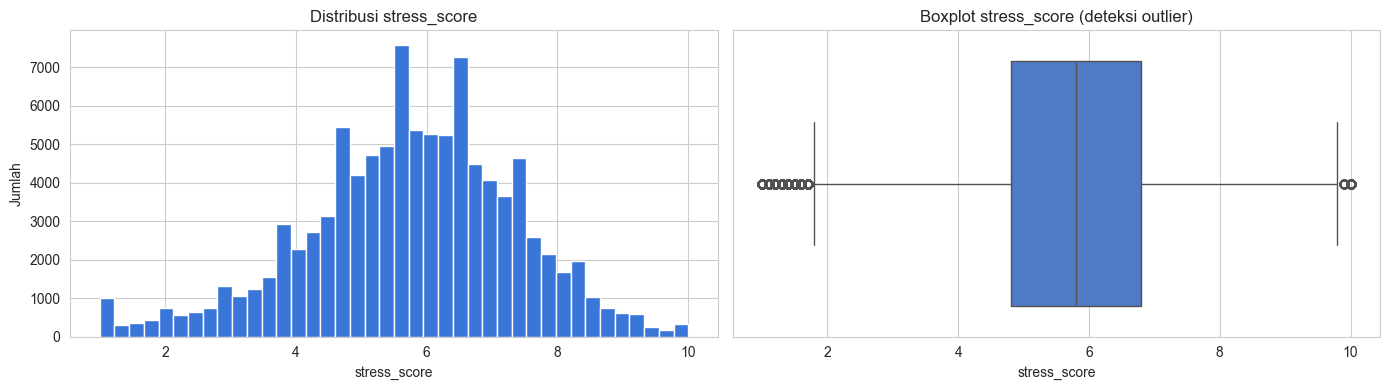


Outlier (IQR rule): 2153 (2.15%)  bounds=[1.80, 9.80]


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df[TARGET], bins=40, color="#3a76d8", edgecolor="white")
axes[0].set_title("Distribusi stress_score")
axes[0].set_xlabel("stress_score"); axes[0].set_ylabel("Jumlah")
sns.boxplot(x=df[TARGET], ax=axes[1], color="#3a76d8")
axes[1].set_title("Boxplot stress_score (deteksi outlier)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/eda_target_distribution.png", dpi=120)
plt.show()

# Outlier IQR
q1, q3 = df[TARGET].quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
n_out = ((df[TARGET] < lo) | (df[TARGET] > hi)).sum()
print(f"\nOutlier (IQR rule): {n_out} ({n_out/len(df)*100:.2f}%)  bounds=[{lo:.2f}, {hi:.2f}]")

### 1.2 Korelasi Numerik vs Target

Heatmap korelasi Pearson — fitur dengan |r| tinggi punya hubungan linear kuat dengan stress_score.

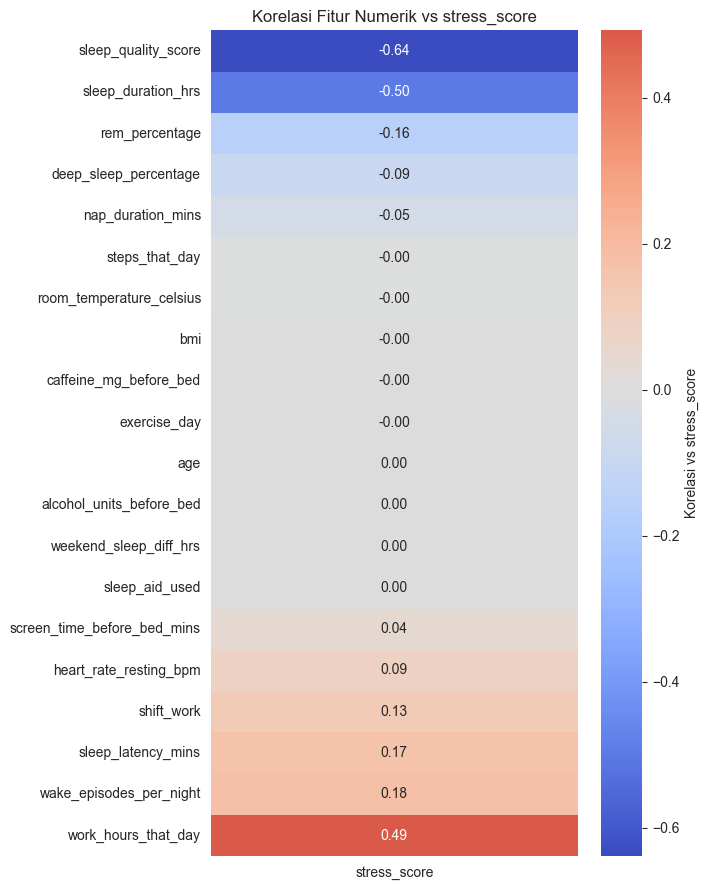


Top-5 korelasi |r| dengan stress_score:
sleep_quality_score       -0.639
sleep_duration_hrs        -0.500
work_hours_that_day        0.493
wake_episodes_per_night    0.175
sleep_latency_mins         0.169


In [4]:
num_corr = df[NUMERIC_FEATURES + [TARGET]].corr()[[TARGET]].drop(TARGET).sort_values(by=TARGET)
plt.figure(figsize=(7, 9))
sns.heatmap(num_corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, cbar_kws={"label": "Korelasi vs stress_score"})
plt.title("Korelasi Fitur Numerik vs stress_score")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/eda_correlation_heatmap.png", dpi=120)
plt.show()

# Top-5 korelasi |r|
corr_abs = df[NUMERIC_FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print("\nTop-5 korelasi |r| dengan stress_score:")
print(corr_abs.head(5).round(3).to_string())

**Insight Phase 1:**
- Dataset clean (0 missing values)
- `sleep_quality_score` korelasi -0.64 (terkuat, negatif)
- `sleep_duration_hrs` -0.50
- `work_hours_that_day` +0.49 — 3 fitur ini akan jadi kandidat utama untuk model
- Distribusi target normal-ish, mean 5.73, ada 2.15% outlier di kedua ekstrem

---

## Phase 2 — Feature Engineering & Preprocessing

**Yang dilakukan:**
1. Drop 4 kolom: `person_id` + 3 co-outcome (mencegah data leakage)
2. Split Train/Validation/Test = 70/15/15 (stratified by stress_score bins)
3. Sanity check leakage

In [5]:
df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
X = df[ALL_FEATURES].copy()
y = df[TARGET].copy()

# Stratified split via stress_score quantile bins
bins = pd.qcut(y, q=5, labels=False, duplicates="drop")
X_temp, X_test, y_temp, y_test, bins_temp, _ = train_test_split(
    X, y, bins, test_size=0.15, random_state=RANDOM_SEED, stratify=bins
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=RANDOM_SEED, stratify=bins_temp
)

# Cast kategorikal ke str (CatBoost butuh string)
for c in CATEGORICAL_FEATURES:
    X_train[c] = X_train[c].astype(str)
    X_val[c] = X_val[c].astype(str)
    X_test[c] = X_test[c].astype(str)

# Sanity check leakage
for col in ["sleep_disorder_risk", "cognitive_performance_score", "felt_rested"]:
    assert col not in X_train.columns
print("[OK] Data leakage guard verified.")

# Tabel ringkasan split
split_summary = pd.DataFrame({
    "n": [len(y_train), len(y_val), len(y_test)],
    "%": [len(y_train)/len(y)*100, len(y_val)/len(y)*100, len(y_test)/len(y)*100],
    "mean": [y_train.mean(), y_val.mean(), y_test.mean()],
    "std": [y_train.std(), y_val.std(), y_test.std()],
}, index=["Train", "Val", "Test"]).round(3)
print("\n=== Split Summary ===")
print(split_summary)

[OK] Data leakage guard verified.

=== Split Summary ===
           n       %   mean    std
Train  69997  69.997  5.734  1.620
Val    15003  15.003  5.724  1.614
Test   15000  15.000  5.741  1.619


**Insight Phase 2:**
- Train: 69,997 (70.00%), Val: 15,003 (15.00%), Test: 15,000 (15.00%)
- Mean & std target konsisten antar split → stratifikasi berhasil
- StandardScaler tidak diperlukan karena tree-based models (CatBoost & RF) invariant terhadap scaling

---

## Phase 3 — Model Training & Comparison

Train **CatBoost** + **Random Forest**, evaluasi R²/RMSE/MAE pada Val + Test, plus 5-Fold CV stability.

Pilih best model berdasarkan R² → digunakan untuk SHAP di Phase 4.

> ⏱️ Estimasi runtime: CatBoost ~2 menit, Random Forest ~1 menit, CV ~2 menit

In [6]:
# ===== CatBoost =====
cat_idx = [X_train.columns.get_loc(c) for c in CATEGORICAL_FEATURES]
train_pool = Pool(X_train, y_train, cat_features=cat_idx)
val_pool = Pool(X_val, y_val, cat_features=cat_idx)

print("[Training CatBoost...]")
t0 = time.time()
cat_model = CatBoostRegressor(
    iterations=1000, learning_rate=0.05, depth=6,
    eval_metric="RMSE", early_stopping_rounds=50,
    random_seed=RANDOM_SEED, verbose=200,
)
cat_model.fit(train_pool, eval_set=val_pool, use_best_model=True)
print(f"CatBoost trained in {time.time()-t0:.1f}s")

[Training CatBoost...]


0:	learn: 1.5747075	test: 1.5675720	best: 1.5675720 (0)	total: 382ms	remaining: 6m 21s


200:	learn: 0.9618674	test: 0.9614372	best: 0.9614372 (200)	total: 25.2s	remaining: 1m 40s


400:	learn: 0.9428499	test: 0.9522338	best: 0.9522338 (400)	total: 49.3s	remaining: 1m 13s


600:	learn: 0.9317572	test: 0.9503331	best: 0.9503331 (600)	total: 1m 14s	remaining: 49.6s


800:	learn: 0.9231419	test: 0.9497680	best: 0.9497103 (774)	total: 1m 41s	remaining: 25.2s


Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9497102676
bestIteration = 774

Shrink model to first 775 iterations.
CatBoost trained in 106.2s


In [7]:
# ===== Random Forest (perlu encoding kategorikal) =====
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_train_rf = X_train.copy()
X_val_rf = X_val.copy()
X_test_rf = X_test.copy()
X_train_rf[CATEGORICAL_FEATURES] = encoder.fit_transform(X_train_rf[CATEGORICAL_FEATURES])
X_val_rf[CATEGORICAL_FEATURES] = encoder.transform(X_val_rf[CATEGORICAL_FEATURES])
X_test_rf[CATEGORICAL_FEATURES] = encoder.transform(X_test_rf[CATEGORICAL_FEATURES])

print("[Training Random Forest...]")
t0 = time.time()
rf_model = RandomForestRegressor(
    n_estimators=300, max_depth=None, min_samples_leaf=5,
    n_jobs=-1, random_state=RANDOM_SEED,
)
rf_model.fit(X_train_rf, y_train)
print(f"RF trained in {time.time()-t0:.1f}s")

[Training Random Forest...]


RF trained in 54.9s


### 3.1 Evaluasi Model (Val + Test)

In [8]:
def metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": mean_absolute_error(y_true, y_pred),
    }

results = {
    "CatBoost": {
        "val": metrics(y_val, cat_model.predict(X_val)),
        "test": metrics(y_test, cat_model.predict(X_test)),
    },
    "RandomForest": {
        "val": metrics(y_val, rf_model.predict(X_val_rf)),
        "test": metrics(y_test, rf_model.predict(X_test_rf)),
    },
}

# Tabel perbandingan
rows = []
for model in ["CatBoost", "RandomForest"]:
    for split in ["val", "test"]:
        m = results[model][split]
        rows.append({"Model": model, "Split": split, **{k: round(v, 4) for k, v in m.items()}})
print(pd.DataFrame(rows).to_string(index=False))

       Model Split     R2   RMSE    MAE
    CatBoost   val 0.6536 0.9497 0.7565
    CatBoost  test 0.6456 0.9639 0.7699
RandomForest   val 0.6278 0.9844 0.7833
RandomForest  test 0.6191 0.9993 0.7980


### 3.2 5-Fold Cross-Validation R² (Stability)

Subsample 30K rows untuk efisiensi.

In [9]:
rng = np.random.RandomState(RANDOM_SEED)
sub_idx = rng.choice(len(X_train), size=30000, replace=False)
X_sub = X_train.iloc[sub_idx].reset_index(drop=True)
y_sub = y_train.iloc[sub_idx].reset_index(drop=True)
X_sub_rf = X_train_rf.iloc[sub_idx].reset_index(drop=True)

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cat_cv, rf_cv = [], []
for fold, (tr, te) in enumerate(kf.split(X_sub), 1):
    cm = CatBoostRegressor(iterations=300, learning_rate=0.05, depth=6,
                           random_seed=RANDOM_SEED, verbose=0)
    cm.fit(Pool(X_sub.iloc[tr], y_sub.iloc[tr], cat_features=cat_idx))
    cat_cv.append(r2_score(y_sub.iloc[te], cm.predict(X_sub.iloc[te])))
    rm = RandomForestRegressor(n_estimators=150, min_samples_leaf=5,
                               n_jobs=-1, random_state=RANDOM_SEED)
    rm.fit(X_sub_rf.iloc[tr], y_sub.iloc[tr])
    rf_cv.append(r2_score(y_sub.iloc[te], rm.predict(X_sub_rf.iloc[te])))
    print(f"  Fold {fold}: CatBoost R2={cat_cv[-1]:.4f}  RF R2={rf_cv[-1]:.4f}")

results["CatBoost"]["cv_r2_mean"] = float(np.mean(cat_cv))
results["CatBoost"]["cv_r2_std"] = float(np.std(cat_cv))
results["RandomForest"]["cv_r2_mean"] = float(np.mean(rf_cv))
results["RandomForest"]["cv_r2_std"] = float(np.std(rf_cv))

print(f"\nCatBoost CV R2 = {results['CatBoost']['cv_r2_mean']:.4f} +/- {results['CatBoost']['cv_r2_std']:.4f}")
print(f"RF       CV R2 = {results['RandomForest']['cv_r2_mean']:.4f} +/- {results['RandomForest']['cv_r2_std']:.4f}")

  Fold 1: CatBoost R2=0.6480  RF R2=0.6236


  Fold 2: CatBoost R2=0.6323  RF R2=0.6093


  Fold 3: CatBoost R2=0.6439  RF R2=0.6195


  Fold 4: CatBoost R2=0.6360  RF R2=0.6109


  Fold 5: CatBoost R2=0.6471  RF R2=0.6221

CatBoost CV R2 = 0.6414 +/- 0.0062
RF       CV R2 = 0.6171 +/- 0.0059


### 3.3 Visual Perbandingan & Best Model

[BEST MODEL] CatBoost


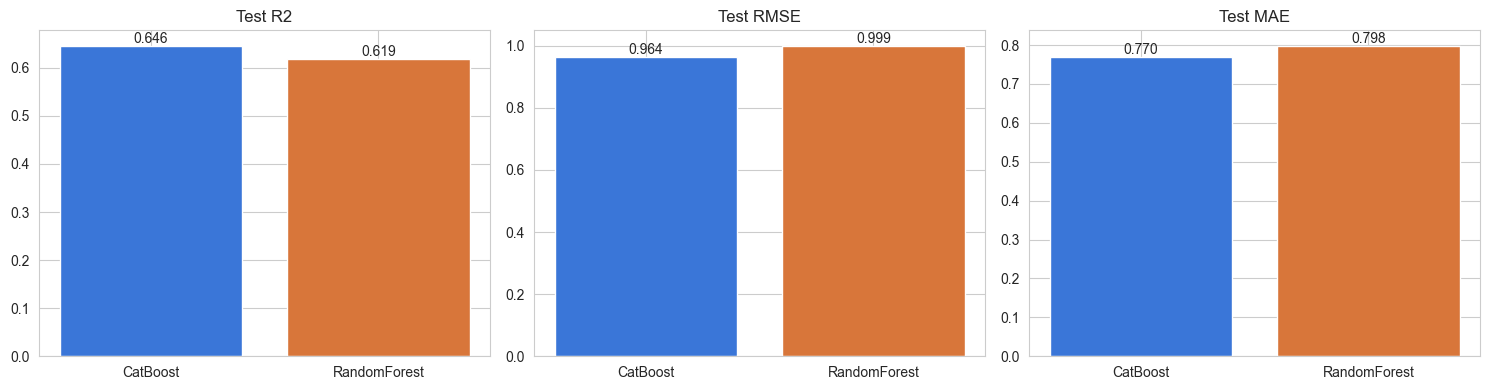

In [10]:
best_name = "CatBoost" if results["CatBoost"]["val"]["R2"] >= results["RandomForest"]["val"]["R2"] else "RandomForest"
print(f"[BEST MODEL] {best_name}")

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for i, m in enumerate(["R2", "RMSE", "MAE"]):
    vals = [results["CatBoost"]["test"][m], results["RandomForest"]["test"][m]]
    bars = ax[i].bar(["CatBoost", "RandomForest"], vals, color=["#3a76d8", "#d8763a"])
    ax[i].set_title(f"Test {m}")
    for b, v in zip(bars, vals):
        ax[i].text(b.get_x()+b.get_width()/2, v, f"{v:.3f}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/model_comparison.png", dpi=120)
plt.show()

with open(f"{OUT_DIR}/model_metrics.json", "w") as f:
    json.dump(results, f, indent=2)

**Insight Phase 3:**
- CatBoost menang di semua metrik (Val + Test + CV)
- Test R² = 0.646, RMSE = 0.964 → memenuhi threshold ≥ 0.6
- CV R² std = 0.006 → sangat stabil antar fold
- **CatBoost dipilih** untuk SHAP analysis di Phase 4

---

## Phase 4 — Global SHAP Analysis

Aplikasi **SHAP TreeExplainer** ke CatBoost (best model).

**Yang dihasilkan:**
1. SHAP values untuk 5,000 sampel test set
2. Sanity check (additivity property)
3. Summary Plot (Beeswarm) — impact + arah
4. Bar Plot — ranking mean |SHAP|
5. Dependence Plots — top-5 fitur
6. Stability — 5-fold CV + Kendall's Tau

In [11]:
# Sample test untuk efisiensi (5K sampel cukup untuk pola global)
n_sample = 5000
rng = np.random.RandomState(RANDOM_SEED)
sample_idx = rng.choice(len(X_test), size=n_sample, replace=False)
X_shap = X_test.iloc[sample_idx].reset_index(drop=True)
y_shap = y_test.iloc[sample_idx].reset_index(drop=True)

print(f"Computing SHAP on {n_sample} test samples...")
explainer = shap.TreeExplainer(cat_model)
shap_pool = Pool(X_shap, cat_features=cat_idx)
shap_values = explainer.shap_values(shap_pool)
expected_value = float(explainer.expected_value)
print(f"SHAP shape: {shap_values.shape}  expected_value: {expected_value:.4f}")

Computing SHAP on 5000 test samples...


SHAP shape: (5000, 27)  expected_value: 5.7337


### 4.1 Sanity Check — SHAP Additivity

Properti matematis SHAP: `prediksi = base_value + Σ(SHAP per fitur)`

Selisih harus mendekati 0 → bukti SHAP konsisten matematis.

In [12]:
preds = cat_model.predict(X_shap)
diff = np.abs(shap_values.sum(axis=1) + expected_value - preds).max()
print(f"max |SHAP_sum + base - pred| = {diff:.10f}")
assert diff < 0.01, "SHAP sanity check FAILED"
print("[PASS] SHAP values are mathematically valid")

max |SHAP_sum + base - pred| = 0.0000000000
[PASS] SHAP values are mathematically valid


### 4.2 Summary Plot (Beeswarm)

- Sumbu X: SHAP value (kontribusi ke prediksi)
- Warna: nilai fitur (merah=tinggi, biru=rendah)
- Setiap titik = 1 individu × 1 fitur

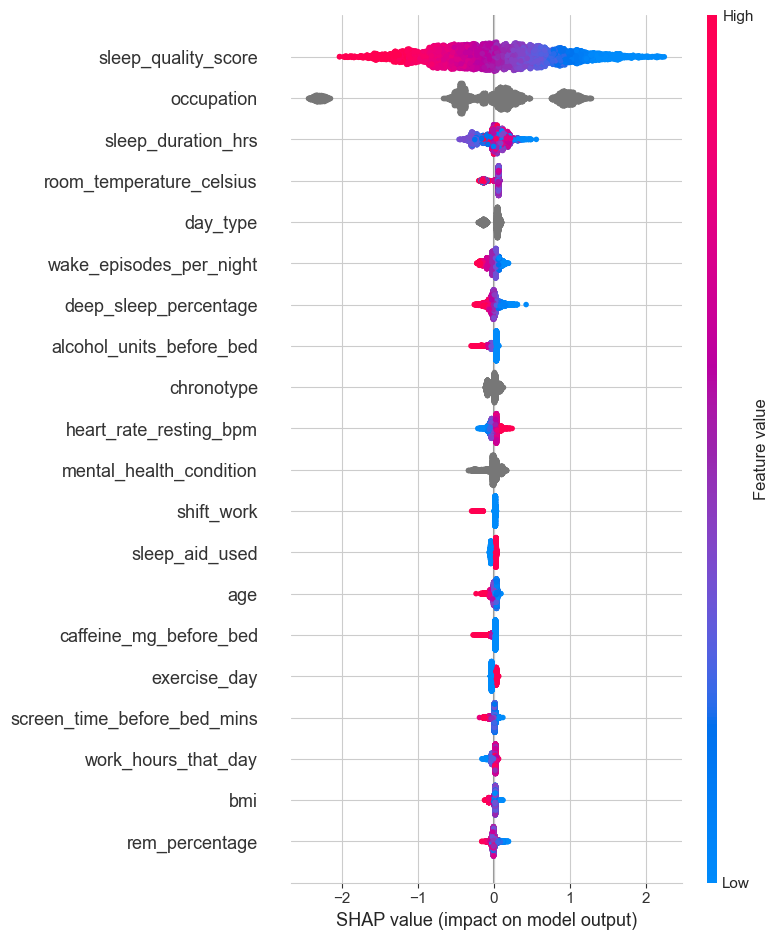

In [13]:
plt.figure()
shap.summary_plot(shap_values, X_shap, show=False, max_display=20)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/shap_summary_beeswarm.png", dpi=120, bbox_inches="tight")
plt.show()

### 4.3 Bar Plot — Ranking Mean |SHAP|

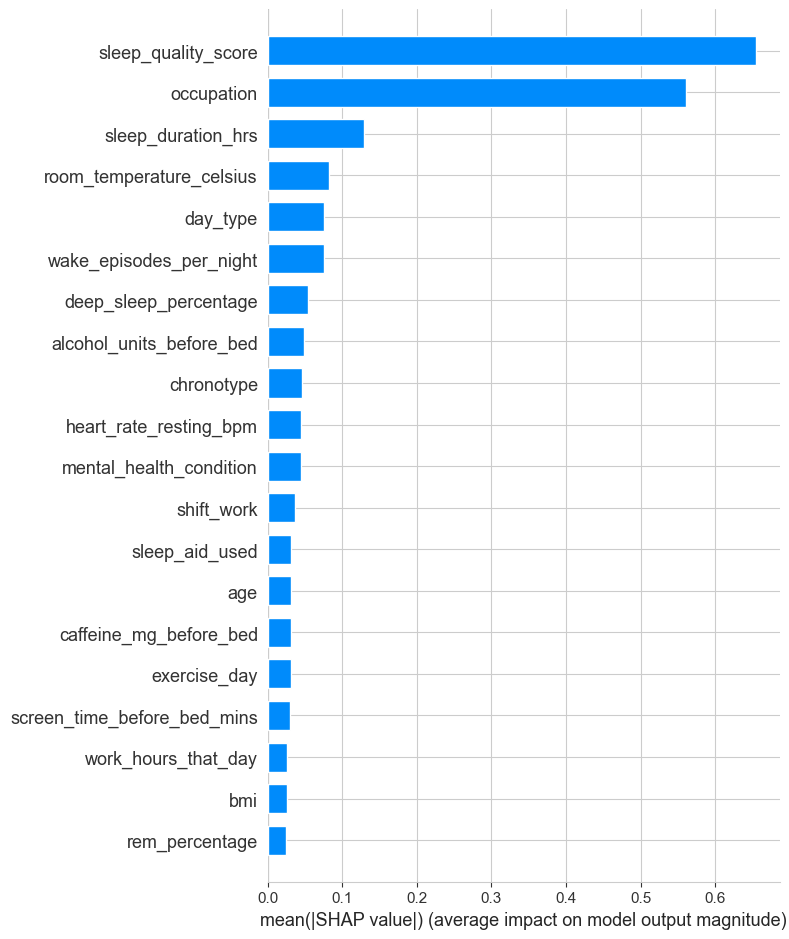


=== Top-10 Feature Importance (mean |SHAP|) ===
sleep_quality_score         0.6542
occupation                  0.5606
sleep_duration_hrs          0.1295
room_temperature_celsius    0.0828
day_type                    0.0758
wake_episodes_per_night     0.0755
deep_sleep_percentage       0.0548
alcohol_units_before_bed    0.0483
chronotype                  0.0464
heart_rate_resting_bpm      0.0445


In [14]:
plt.figure()
shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False, max_display=20)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/shap_bar_importance.png", dpi=120, bbox_inches="tight")
plt.show()

# Top-10 print
mean_abs_shap = np.abs(shap_values).mean(axis=0)
feat_imp = pd.Series(mean_abs_shap, index=X_shap.columns).sort_values(ascending=False)
print("\n=== Top-10 Feature Importance (mean |SHAP|) ===")
print(feat_imp.head(10).round(4).to_string())

### 4.4 Dependence Plots — Top-5 Fitur

Menunjukkan bagaimana SHAP value berubah seiring perubahan nilai fitur. Warna = fitur yang paling berinteraksi.

Top-5 fitur: ['sleep_quality_score', 'occupation', 'sleep_duration_hrs', 'room_temperature_celsius', 'day_type']


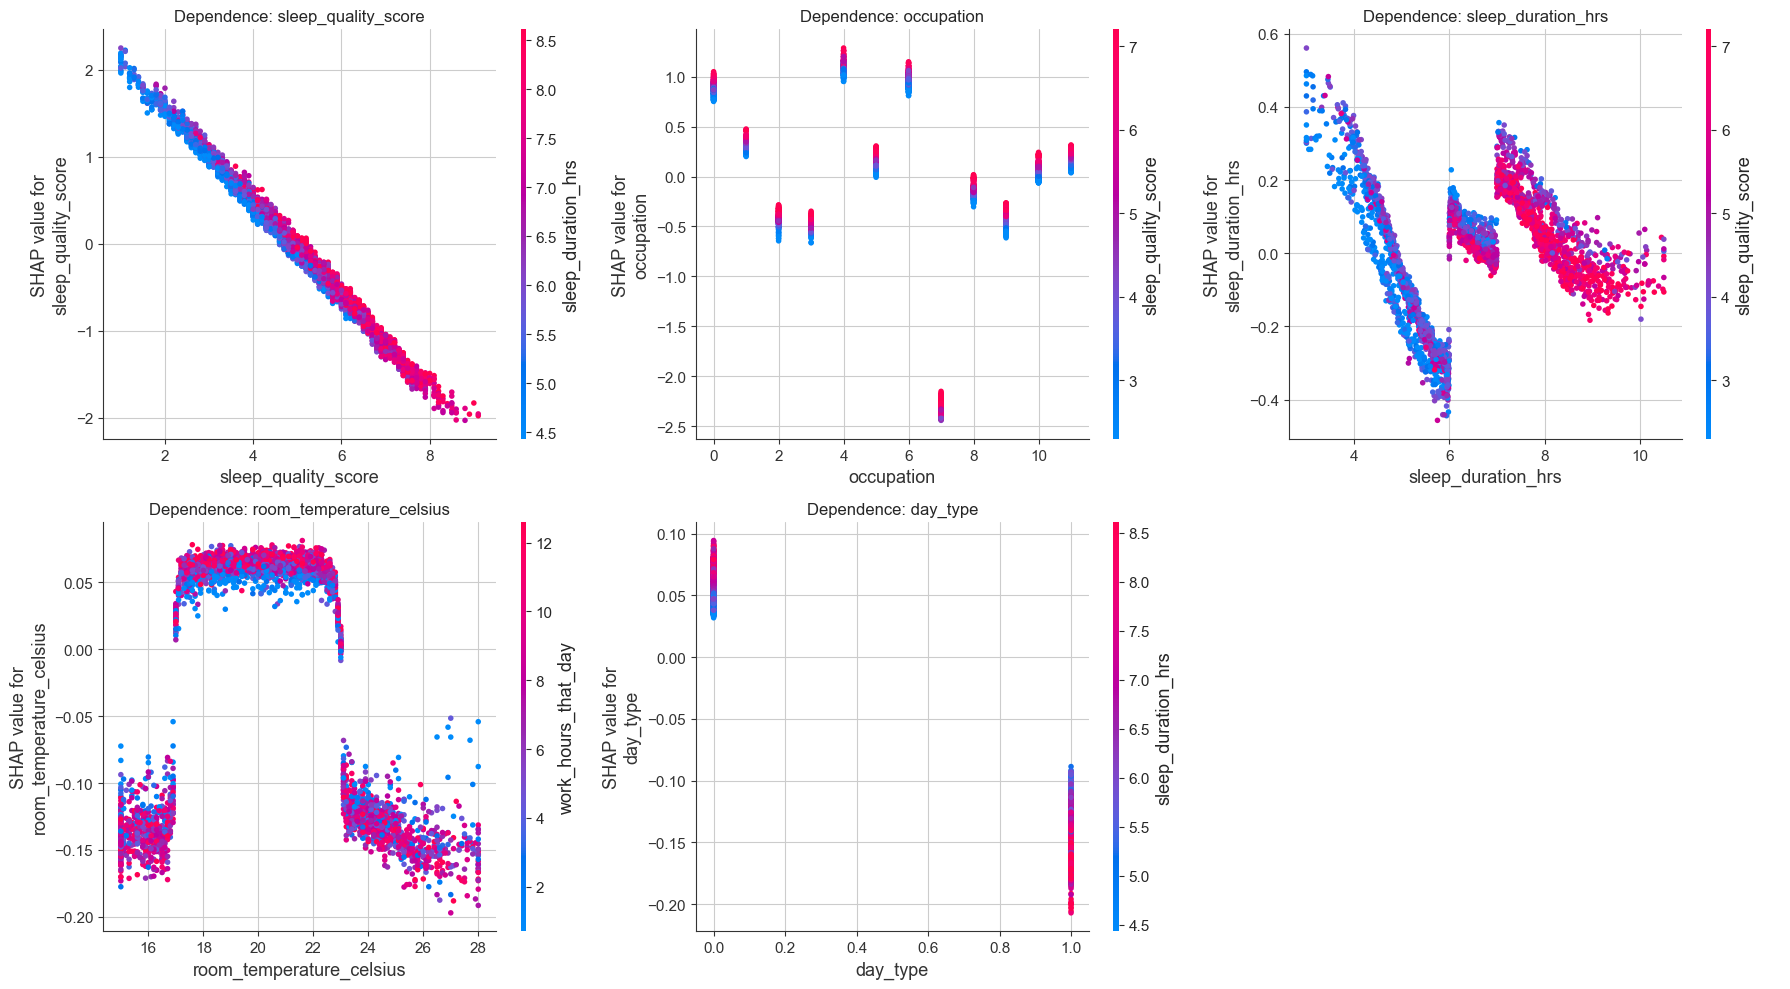

In [15]:
top5 = feat_imp.head(5).index.tolist()
print(f"Top-5 fitur: {top5}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, feat in enumerate(top5):
    if feat in CATEGORICAL_FEATURES:
        X_dep = X_shap.copy()
        X_dep[feat] = pd.Categorical(X_dep[feat]).codes
        shap.dependence_plot(feat, shap_values, X_dep, ax=axes[i], show=False)
    else:
        shap.dependence_plot(feat, shap_values, X_shap, ax=axes[i], show=False)
    axes[i].set_title(f"Dependence: {feat}")
axes[-1].axis("off")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/shap_dependence_top5.png", dpi=120)
plt.show()

### 4.5 Stability Analysis — 5-Fold CV SHAP + Kendall's Tau

Ranking fitur harus konsisten antar fold → bukti SHAP findings bisa di-generalize.

  Fold 1 top-3: ['sleep_quality_score', 'occupation', 'sleep_duration_hrs']


  Fold 2 top-3: ['sleep_quality_score', 'occupation', 'sleep_duration_hrs']


  Fold 3 top-3: ['sleep_quality_score', 'occupation', 'sleep_duration_hrs']


  Fold 4 top-3: ['sleep_quality_score', 'occupation', 'sleep_duration_hrs']


  Fold 5 top-3: ['sleep_quality_score', 'occupation', 'sleep_duration_hrs']

Mean pairwise Kendall's Tau: 0.8963  (target >= 0.80)


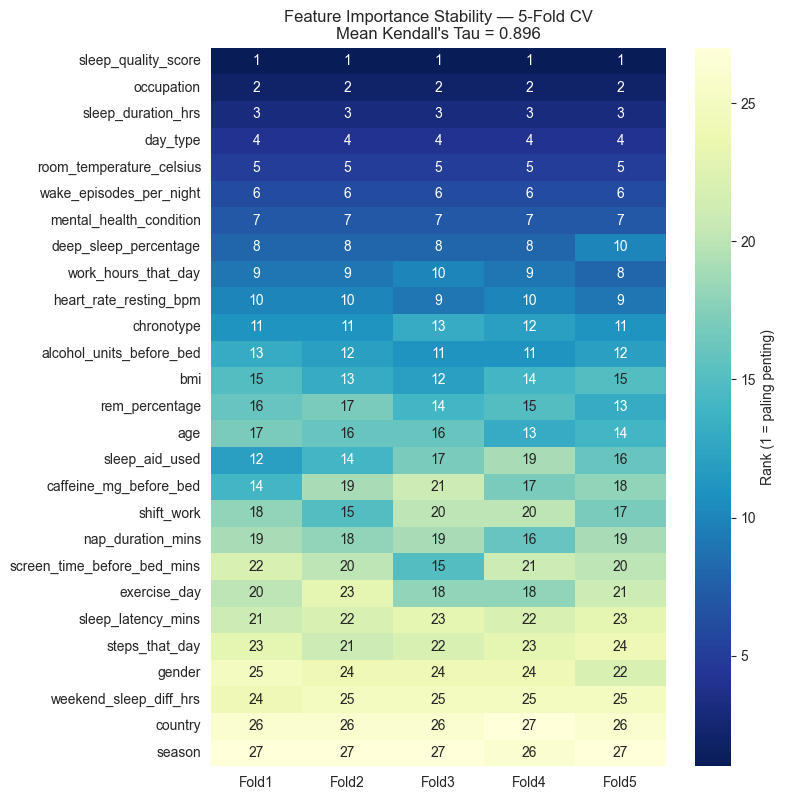

In [16]:
rng = np.random.RandomState(RANDOM_SEED)
sub_idx = rng.choice(len(X_train), size=20000, replace=False)
X_sub = X_train.iloc[sub_idx].reset_index(drop=True)
y_sub = y_train.iloc[sub_idx].reset_index(drop=True)

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
fold_rankings = []
for fold, (tr, te) in enumerate(kf.split(X_sub), 1):
    cm = CatBoostRegressor(iterations=300, learning_rate=0.05, depth=6,
                           random_seed=RANDOM_SEED, verbose=0)
    cm.fit(Pool(X_sub.iloc[tr], y_sub.iloc[tr], cat_features=cat_idx))
    sv = shap.TreeExplainer(cm).shap_values(Pool(X_sub.iloc[te], cat_features=cat_idx))
    imp = np.abs(sv).mean(axis=0)
    ranking = pd.Series(imp, index=X_sub.columns).rank(ascending=False).astype(int)
    fold_rankings.append(ranking)
    print(f"  Fold {fold} top-3: {ranking.sort_values().head(3).index.tolist()}")

# Pairwise Kendall's Tau
taus = []
for i in range(5):
    for j in range(i+1, 5):
        tau, _ = kendalltau(fold_rankings[i], fold_rankings[j])
        taus.append(tau)
mean_tau = float(np.mean(taus))
print(f"\nMean pairwise Kendall's Tau: {mean_tau:.4f}  (target >= 0.80)")

# Heatmap
rank_df = pd.concat(fold_rankings, axis=1)
rank_df.columns = [f"Fold{i+1}" for i in range(5)]
rank_df["mean_rank"] = rank_df.mean(axis=1)
rank_df = rank_df.sort_values("mean_rank")
plt.figure(figsize=(8, max(8, len(rank_df)*0.3)))
sns.heatmap(rank_df[[f"Fold{i+1}" for i in range(5)]],
            annot=True, fmt=".0f", cmap="YlGnBu_r",
            cbar_kws={"label": "Rank (1 = paling penting)"})
plt.title(f"Feature Importance Stability — 5-Fold CV\nMean Kendall's Tau = {mean_tau:.3f}")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/shap_stability_heatmap.png", dpi=120)
plt.show()

**Insight Phase 4:**
- **Top-3 fitur identik di semua 5 fold:** `sleep_quality_score`, `occupation`, `sleep_duration_hrs`
- **Kendall's Tau = 0.896** — sangat stabil (target ≥ 0.80)
- **Surprise:** `work_hours_that_day` (korelasi linear 0.49) **tidak masuk top-10 SHAP** karena `occupation` (rank #2) sudah menyerap info pola kerja per profesi

---

## Phase 5 — Individual SHAP Analysis

Pilih 3 individu representatif (High/Low/Borderline stress), tunjukkan kontribusi per fitur dengan **Waterfall Plot** + narasi natural.

In [17]:
preds = cat_model.predict(X_shap)
high_idx = int(np.argmax(preds))
low_idx = int(np.argmin(preds))
border_idx = int(np.argmin(np.abs(preds - 5.0)))

cases = {"high_stress": high_idx, "low_stress": low_idx, "borderline": border_idx}
print("Selected cases:", cases)
for label, idx in cases.items():
    print(f"  {label:12s}: idx={idx}  predicted={preds[idx]:.2f}  actual={y_shap.iloc[idx]:.2f}")

Selected cases: {'high_stress': 2731, 'low_stress': 1149, 'borderline': 3816}
  high_stress : idx=2731  predicted=9.05  actual=10.00
  low_stress  : idx=1149  predicted=1.57  actual=1.00
  borderline  : idx=3816  predicted=5.00  actual=4.60


### 5.1 Waterfall Plots

Menampilkan bagaimana tiap fitur "mendorong" prediksi dari baseline ke nilai akhir.

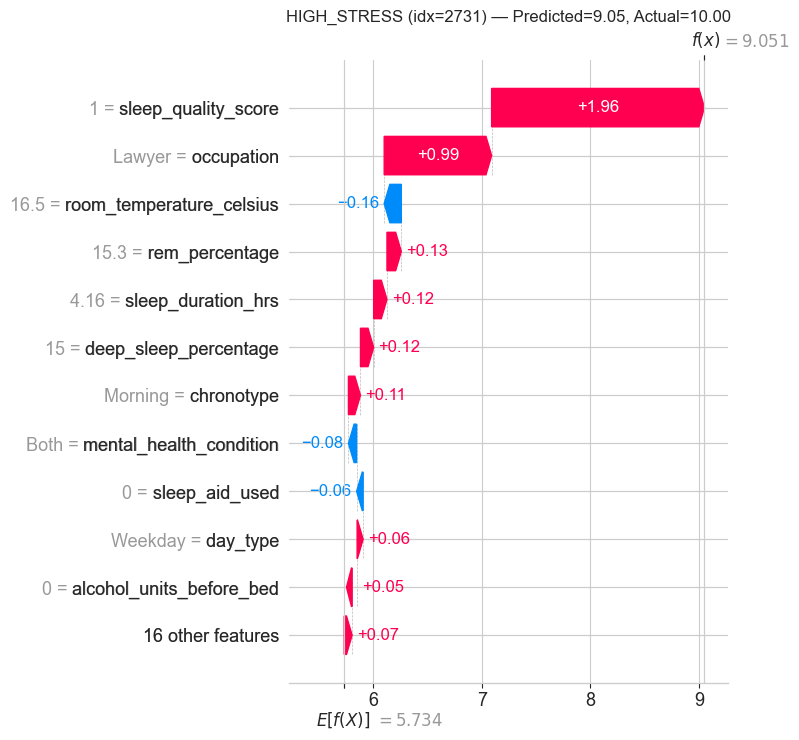

Individu #2731 memiliki stress_score aktual 10.00 dan diprediksi 9.05 (baseline: 5.73).
  Faktor PENINGKAT stres terbesar:
    - sleep_quality_score = 1.0 (SHAP +1.960)
    - occupation = Lawyer (SHAP +0.989)
    - rem_percentage = 15.3 (SHAP +0.132)
  Faktor PENEKAN stres terbesar:
    - room_temperature_celsius = 16.5 (SHAP -0.158)
    - mental_health_condition = Both (SHAP -0.075)
    - sleep_aid_used = 0 (SHAP -0.060)



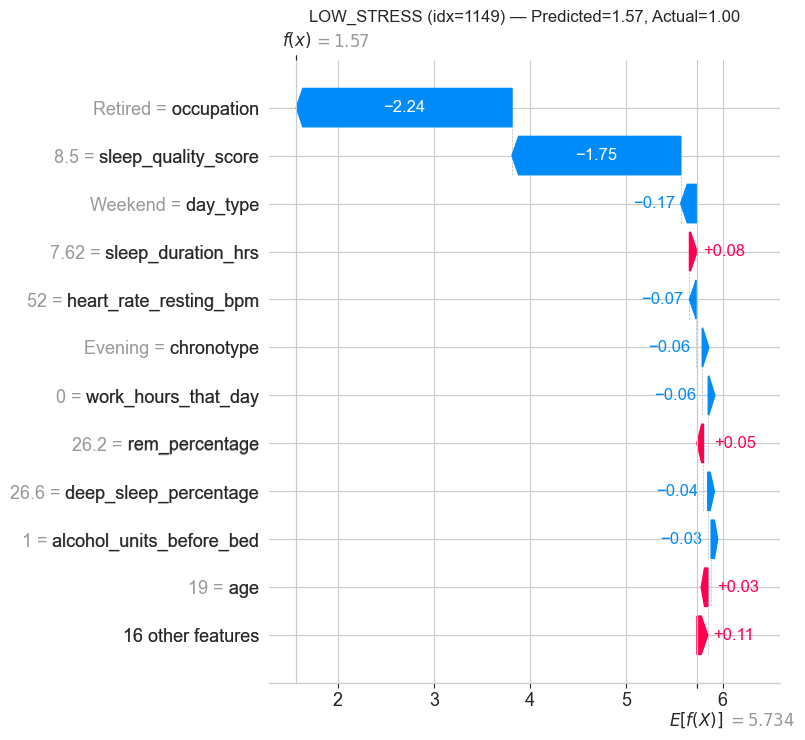

Individu #1149 memiliki stress_score aktual 1.00 dan diprediksi 1.57 (baseline: 5.73).
  Faktor PENINGKAT stres terbesar:
    - sleep_duration_hrs = 7.62 (SHAP +0.080)
    - rem_percentage = 26.2 (SHAP +0.050)
    - age = 19 (SHAP +0.034)
  Faktor PENEKAN stres terbesar:
    - occupation = Retired (SHAP -2.243)
    - sleep_quality_score = 8.5 (SHAP -1.753)
    - day_type = Weekend (SHAP -0.171)



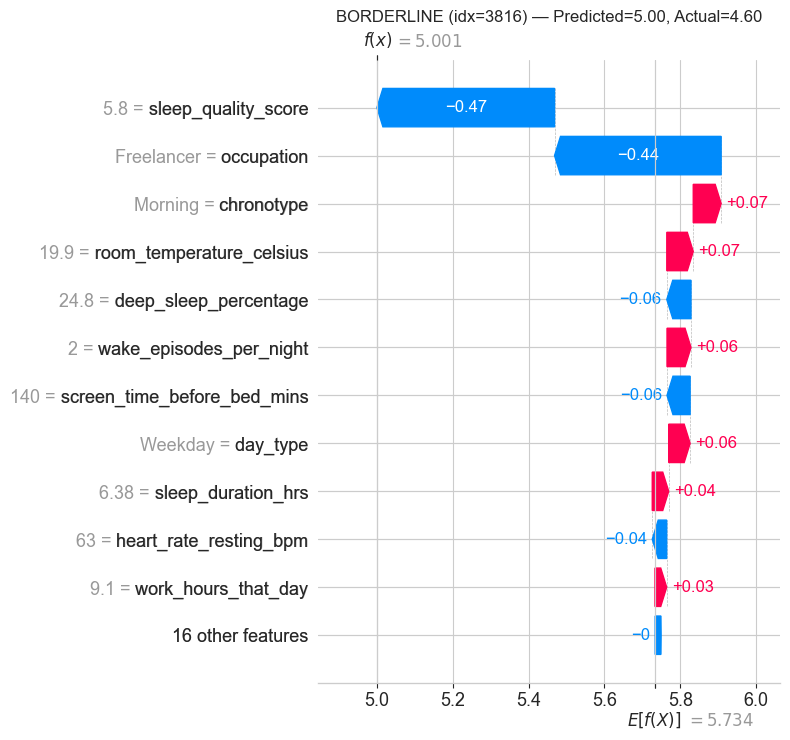

Individu #3816 memiliki stress_score aktual 4.60 dan diprediksi 5.00 (baseline: 5.73).
  Faktor PENINGKAT stres terbesar:
    - chronotype = Morning (SHAP +0.074)
    - room_temperature_celsius = 19.9 (SHAP +0.070)
    - wake_episodes_per_night = 2 (SHAP +0.063)
  Faktor PENEKAN stres terbesar:
    - sleep_quality_score = 5.8 (SHAP -0.468)
    - occupation = Freelancer (SHAP -0.439)
    - deep_sleep_percentage = 24.8 (SHAP -0.064)



In [18]:
feature_names = X_shap.columns.tolist()
narratives = {}

for label, idx in cases.items():
    pred = float(preds[idx])
    actual = float(y_shap.iloc[idx])
    sv = shap_values[idx]

    explanation = shap.Explanation(
        values=sv, base_values=expected_value,
        data=X_shap.iloc[idx].values, feature_names=feature_names,
    )
    plt.figure()
    shap.plots.waterfall(explanation, max_display=12, show=False)
    plt.title(f"{label.upper()} (idx={idx}) — Predicted={pred:.2f}, Actual={actual:.2f}")
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/shap_waterfall_{label}.png", dpi=120, bbox_inches="tight")
    plt.show()

    # Generate narrative
    contrib = pd.Series(sv, index=feature_names).sort_values(key=abs, ascending=False)
    top_pos = contrib[contrib > 0].head(3)
    top_neg = contrib[contrib < 0].head(3)
    feat_vals = X_shap.iloc[idx]

    narrative = (
        f"Individu #{idx} memiliki stress_score aktual {actual:.2f} "
        f"dan diprediksi {pred:.2f} (baseline: {expected_value:.2f}).\n"
        f"  Faktor PENINGKAT stres terbesar:\n"
    )
    for f, v in top_pos.items():
        narrative += f"    - {f} = {feat_vals[f]} (SHAP +{v:.3f})\n"
    narrative += "  Faktor PENEKAN stres terbesar:\n"
    for f, v in top_neg.items():
        narrative += f"    - {f} = {feat_vals[f]} (SHAP {v:.3f})\n"
    narratives[label] = narrative
    print(narrative)

### 5.2 Force Plot Interaktif (HTML)

Force Plot adalah visualisasi interaktif. Disimpan sebagai HTML untuk presentasi.

In [19]:
high_idx = cases["high_stress"]
force = shap.force_plot(
    expected_value, shap_values[high_idx], X_shap.iloc[high_idx],
    feature_names=feature_names,
)
shap.save_html(f"{OUT_DIR}/force_plot.html", force)
print(f"[OK] force_plot.html saved — buka di browser untuk versi interaktif")

# Save narratives ke file
with open(f"{OUT_DIR}/individual_narratives.txt", "w", encoding="utf-8") as f:
    for label, narr in narratives.items():
        f.write(f"=== {label.upper()} ===\n{narr}\n")

# Display force plot inline
shap.initjs()
force

[OK] force_plot.html saved — buka di browser untuk versi interaktif


**Insight Phase 5:**
- **High stress (Lawyer + sleep_quality 1.0/10):** sleep_quality_score buruk (+1.96) + occupation Lawyer (+0.99) jadi 2 faktor utama
- **Low stress (Retired + sleep_quality 8.5/10):** Retired (-2.24) + sleep_quality bagus (-1.75) menekan stres signifikan
- **Borderline (Freelancer):** faktor kecil-kecil (~0.4 max) → memang seimbang

---

## Phase 6 — Verification Tests & Final Summary

Automated tests untuk memastikan pipeline valid + ringkas insight final.

In [20]:
# ===== Test 1: Data leakage guard =====
print("[Test 1] Data leakage guard")
for col in ["sleep_disorder_risk", "cognitive_performance_score", "felt_rested", "person_id"]:
    assert col not in X_train.columns
    print(f"  PASS: {col} not in X_train.columns")

# ===== Test 2: SHAP sanity =====
print("\n[Test 2] SHAP additivity")
diff = np.abs(shap_values.sum(axis=1) + expected_value - cat_model.predict(X_shap)).max()
assert diff < 0.01
print(f"  PASS: max diff = {diff:.10f}")

# ===== Test 3: R² threshold =====
print("\n[Test 3] R² >= 0.6")
r2 = r2_score(y_test, cat_model.predict(X_test))
assert r2 >= 0.6
print(f"  PASS: R² = {r2:.4f}")

# ===== Test 4: 9 output visuals exist =====
print("\n[Test 4] 9 plan-required visuals exist")
required = [
    "model_comparison.png", "shap_summary_beeswarm.png", "shap_bar_importance.png",
    "shap_dependence_top5.png", "shap_stability_heatmap.png",
    "shap_waterfall_high_stress.png", "shap_waterfall_low_stress.png",
    "shap_waterfall_borderline.png", "force_plot.html",
]
for fname in required:
    p = f"{OUT_DIR}/{fname}"
    assert os.path.exists(p), f"Missing: {fname}"
    print(f"  PASS: {fname} ({os.path.getsize(p)/1024:.1f} KB)")

print("\n=== ALL 4 TESTS PASSED ===")

[Test 1] Data leakage guard
  PASS: sleep_disorder_risk not in X_train.columns
  PASS: cognitive_performance_score not in X_train.columns
  PASS: felt_rested not in X_train.columns
  PASS: person_id not in X_train.columns

[Test 2] SHAP additivity
  PASS: max diff = 0.0000000000

[Test 3] R² >= 0.6
  PASS: R² = 0.6456

[Test 4] 9 plan-required visuals exist
  PASS: model_comparison.png (30.6 KB)
  PASS: shap_summary_beeswarm.png (116.6 KB)
  PASS: shap_bar_importance.png (75.1 KB)
  PASS: shap_dependence_top5.png (358.1 KB)
  PASS: shap_stability_heatmap.png (107.8 KB)
  PASS: shap_waterfall_high_stress.png (83.0 KB)
  PASS: shap_waterfall_low_stress.png (81.6 KB)
  PASS: shap_waterfall_borderline.png (87.6 KB)
  PASS: force_plot.html (347.5 KB)

=== ALL 4 TESTS PASSED ===


### Final Summary

In [21]:
summary = {
    "best_model": best_name,
    "test_metrics": results[best_name]["test"],
    "cv_r2_mean": results[best_name]["cv_r2_mean"],
    "cv_r2_std": results[best_name]["cv_r2_std"],
    "shap_stability_kendall_tau": mean_tau,
    "top10_features": feat_imp.head(10).round(4).to_dict(),
    "individual_cases": cases,
}

with open(f"{OUT_DIR}/summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2, default=str))

{
  "best_model": "CatBoost",
  "test_metrics": {
    "R2": 0.6456320383867951,
    "RMSE": 0.9639067532957202,
    "MAE": 0.7698876138075572
  },
  "cv_r2_mean": 0.6414323225489396,
  "cv_r2_std": 0.006239949291930837,
  "shap_stability_kendall_tau": 0.8962962962962964,
  "top10_features": {
    "sleep_quality_score": 0.6542,
    "occupation": 0.5606,
    "sleep_duration_hrs": 0.1295,
    "room_temperature_celsius": 0.0828,
    "day_type": 0.0758,
    "wake_episodes_per_night": 0.0755,
    "deep_sleep_percentage": 0.0548,
    "alcohol_units_before_bed": 0.0483,
    "chronotype": 0.0464,
    "heart_rate_resting_bpm": 0.0445
  },
  "individual_cases": {
    "high_stress": 2731,
    "low_stress": 1149,
    "borderline": 3816
  }
}


---

## Insight Actionable

1. **Sleep quality is king** — `sleep_quality_score` adalah prediktor #1 dengan SHAP 4× lebih besar dari `sleep_duration_hrs`. Intervensi sebaiknya fokus ke **kualitas** tidur (lingkungan, rutinitas), bukan hanya kuantitas.

2. **Occupation > work_hours** — Pola pekerjaan (Lawyer +0.99 vs Retired -2.24) memberi efek SHAP hingga ±2.2, jauh melebihi jam kerja standalone. Untuk corporate wellness, **profesi-spesifik** lebih efektif.

3. **Lingkungan kamar tidur underrated** — `room_temperature_celsius` masuk top-5, sering diabaikan dibanding screen time/kafein. Optimal 16-19°C.

4. **Temuan dapat di-generalize** — Stability score Kendall's Tau **0.896** + SHAP sanity perfect (selisih 0.000) → bukan artifact data.

---

## Output Files Generated

Semua file ada di folder `outputs/`:

| Kategori | File |
| --- | --- |
| EDA | `eda_target_distribution.png`, `eda_correlation_heatmap.png` |
| Model | `model_comparison.png`, `model_metrics.json` |
| Global SHAP | `shap_summary_beeswarm.png`, `shap_bar_importance.png`, `shap_dependence_top5.png`, `shap_stability_heatmap.png` |
| Individual SHAP | `shap_waterfall_*.png` (3 file), `force_plot.html`, `individual_narratives.txt` |
| Final Report | `summary.json` |
